## Part 1 — Architecture Understanding

### Task 1.1: Forward Pass Explanation

Describe the full data flow in LLaVA:
1. Image input
2. Vision encoder (CLIP)
3. Projection layer
4. Language model input
5. Text generation

Answer:
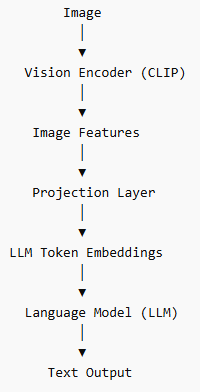

1. Image Input - The input image is first resized, normalized and converted to patches. These patches are fed into the vision transformer.
2. Vision Encoder - LLaVA uses the vision encoder from CLIP. CLIP converts the image into vectors. These vectors are visual tokens representing objects, shapes and textures. But these are not words, they are numeric vectors.
3. Projection Layer - This is a linear layer. This layer is required because the CLIP embedding size and LLM embedding size may not be equal. The CLIP output may be 512 dimension and LLM may expect 1024 dimension. Hence this layer maps the visual feature to the LLM embedding space. After projection, the image features looks like token embeddings that the LLM understands. 
4. Language model input - The mixed sequence of image tokens and text tokens are combined and fed to the Large Language Model (LLM) like LLaMA.
5. The LLM processes the sequence using self-attention - images tokens attend to text tokens and vice versa. This way the model learns the relationship between visual features and words. 

This way, the image embeddings are inserted into the token embedding sequence just like words. The LLM does not see the image directly instead as embeddings that represent the image. 

### Task 1.2: Projection Layer Intuition

LaVA maps vision features into the language model space:

z=W⋅f~vision~(x)

- Why a simple linear or MLP projection works
- What assumption is made about embedding spaces
- What could go wrong if alignment is poor

Answer: The simple linear or MLP projection works because both models already learn semantic embeddings and organize information semantically in vector space. So the projection layer just needs to rotate or scale one embedding space into another. 

The projection approach assumes that vision embeddings and language embeddings have similar semantic and can be linearly aligned. In other words, the concepts are organized similarly in both spaces and a linear transformation can align them. This is called shared semantic space assumption.

If the projection layer does not align with the spaces well, the below problems can occur.
1. Hallucinations - The LLM may generate incorrect descriptions because image embeddings land in a wrong semantic region. 
2. If embeddings are poorly aligned, the LLM may ignore images tokens entirely and rely only on the text prompt.
3. The loss may not decrease, random text may get produced and training becomes unstable.

### Task 1.3: Key Design Choice
Answer: Instead of retraining the entire vision and language model together, LLaVA keeps both frozen and only trains a small projection layer to connect them. This dramatically reduces training cost, data needed and training time. But this design assumes that both vision and language model already has semantic knowledge and only needs to be aligned. So the projection layer is basically a translator between embedding spaces.

**Why does LLaVA avoid cross-attention (used in models like Flamingo) and instead inject projected tokens directly into the LLM?**
1. Simplicity:
Cross-attention requires adding new attention layers, modifying the LLM architecture, training new multimodal blacks and complex training pipeline which is architecturally complex. LLaVA approach is simpler as it does not need new attention layers or architecture modification. Hence the LLM remains unchanged. This is powerful because existing LLMs can be used and prepending image tokens like they are words.

2. Efficiency:
LLaVA only adds a small projection MLP but Flamingo with cross-attention layers adds many parameters, multiple layers and memory cost.
LLaVA is much cheaper to train compared to Flamingo because it can freeze CLIP/LLM and trains only projection layer.

3. Limitations
Visual transformation may get diluted as LLaVA injects image tokens only at the beginning. Later layers may focus mostly on text. 
Also image tokens are fixed after projection. There is no dynamic attention between image regions and words at each layer.
Image tokens consume part of the LLM context window.


## Part 2 - Training Pipeline

### Task 2.1: Two-Stage Training
Explain the two stages:
1. Feature alignment
2. Visual instruction tuning

Answer:
The training objective is the standard language modeling loss. The model tries to predict the next word given the image and previous words.
1. Feature Alignment - In this first stage, the model aligns vision encoder features with language model embedding space. This stage teaches the model how images relate to words.
2. Visual Instruction Tuning - After alignment, the model can connect images to words, but it cannot yet follow instructions. So in stage 2, the model is trained on instruction-style datasets. In this stage, the model learns on how to answer questions about images, how to follow instructions, conversion format, reasoning about images and chat-style responses. 

If we keep only Stage 1, then model can describe images but can not follow instructions or answer questions. 
If we keep only Stage 2, then model does not understand image embeddings at all as embedding spaces are not aligned. Image tokens looks like noise to the LLM.
So the pipeline must be:
Stage 1 -> Learn image alignment
Stage 2 -> Learn instruction following and conversation.

Hence both stages are necessary.

### Task 2.2: Synthetic Data
LLaVA uses GPT-generated instruction data.

Answer:
1. Why is synthetic data used instead of human annotation?
2. What biases might this introduce?
3. Does this limit generalization?

1. LLaVA uses synthetic instruction data instead of relying only on human-labeled datasets. This is a very important design decision in the training pipeline and the main reason is human annotation is expensive and slow. 

2. As the data is generated by a language model, the dataset reflects the biases of that language model. The answers may sound very polite, very descriptive. The LLM might add some information which may not be visible in the image. Training on this kind of data, the model learns to guess details not present in the image which could increase hallucinations in multimodal models. Synthetic instructions may not reflect real user questions. 

3. Yes, synthetic data limits generalization but not completely with possible limitations on question diversity, hallucinated answers, style bias, missing edge cases, overfitting to GPT style responses.


### Part 3 — Reflection
Answer the following clearly:

**1. Is LLaVA truly multimodal, or is it a language model conditioned on visual features?**

LLaVA is technically multimodal, but architecturally it is a language model conditioned on visual embeddings rather than a fully joint multimodal model. 

**2. Where does alignment actually happen — projection layer or instruction tuning?**

Alignment in LLaVA occurs at two levels. Embedding alignment happens in the projection layer (Stage 1), while behavior/ instruction alignment happens during instruction tuning which is Stage 2. 

**3. What is the biggest limitation of this architecture?**

The biggest limitation of LLaVA is that it is essentially a language model conditioned on static image embeddings, so it cannot fully reason over visual information the way a model with deep cross-modal layers can.